# ML-Based Sentiment Analysis

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# Built-in English stopwords (no NLTK download required)
STOP_WORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than','too',
    'very','s','t','can','will','just','don','should','now','d','ll','m','o',
    're','ve','y','ain','aren','couldn','didn','doesn','hadn','hasn','haven',
    'isn','ma','mightn','mustn','needn','shan','shouldn','wasn','weren','won','wouldn'
}

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset

> **Note:** Place `IMDB Dataset.csv` in the same directory as this notebook before running.

In [2]:
df = pd.read_csv('IMDB Dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSentiment Distribution:")
print(df['sentiment'].value_counts())
df.head(3)

Dataset Shape: (50000, 2)
Columns: ['review', 'sentiment']

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


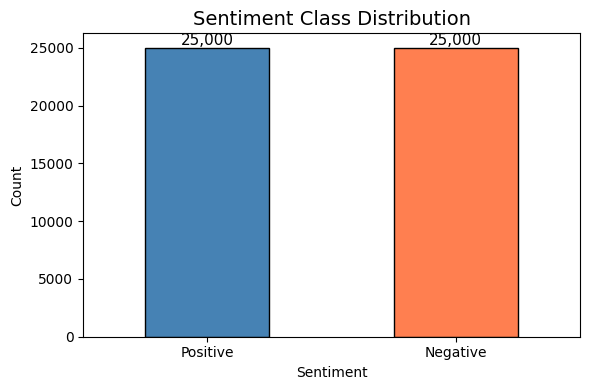

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
df['sentiment'].value_counts().plot(
    kind='bar', color=['steelblue', 'coral'], ax=ax, edgecolor='black', width=0.5
)
ax.set_title('Sentiment Class Distribution', fontsize=14)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.set_xticklabels(['Positive', 'Negative'], rotation=0)
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height()):,}',
                (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Text Preprocessing

In [4]:
def preprocess_text(text):
    """Clean raw review text."""
    text = text.lower()                              # Lowercase
    text = re.sub(r'<.*?>', ' ', text)               # Remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # Remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)           # Keep letters only
    text = re.sub(r'\s+', ' ', text).strip()        # Extra whitespace
    return text

df['clean_review'] = df['review'].apply(preprocess_text)

print("=== BEFORE PREPROCESSING ===")
print(df['review'].iloc[0][:300])
print("\n=== AFTER PREPROCESSING ===")
print(df['clean_review'].iloc[0][:300])

=== BEFORE PREPROCESSING ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

=== AFTER PREPROCESSING ===
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not 


## 4. Tokenization & Stopword Removal


In [5]:
def tokenize_and_filter(text):
    """Tokenize, remove stopwords, and filter short tokens."""
    tokens = text.split()                                          # Tokenize
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]  # Filter
    return ' '.join(tokens)

df['processed_review'] = df['clean_review'].apply(tokenize_and_filter)

df['token_count'] = df['processed_review'].apply(lambda x: len(x.split()))
print("=== AFTER TOKENIZATION + STOPWORD REMOVAL ===")
print(df['processed_review'].iloc[0][:300])
print(f"\nAvg tokens/review : {df['token_count'].mean():.1f}")
print(f"Min tokens        : {df['token_count'].min()}")
print(f"Max tokens        : {df['token_count'].max()}")

=== AFTER TOKENIZATION + STOPWORD REMOVAL ===
one reviewers mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scenes violence set right word trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called nickname given oswald maximum security state pe

Avg tokens/review : 116.9
Min tokens        : 3
Max tokens        : 1392


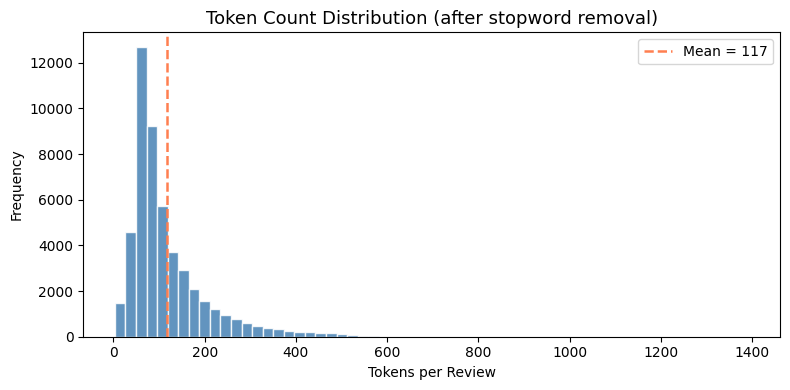

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['token_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['token_count'].mean(), color='coral', linestyle='--', linewidth=1.8,
           label=f"Mean = {df['token_count'].mean():.0f}")
ax.set_title('Token Count Distribution (after stopword removal)', fontsize=13)
ax.set_xlabel('Tokens per Review')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Encode labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['processed_review']
y = df['label']

# Train / Test split  (80 / 20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF matrix (train) : {X_train_tfidf.shape}")
print(f"TF-IDF matrix (test)  : {X_test_tfidf.shape}")

feature_names = tfidf.get_feature_names_out()
print(f"\nSample features: {feature_names[:20].tolist()}")

Training samples : 40,000
Testing  samples : 10,000

TF-IDF matrix (train) : (40000, 10000)
TF-IDF matrix (test)  : (10000, 10000)

Sample features: ['aaron', 'abandoned', 'abbott', 'abc', 'abilities', 'ability', 'able', 'able get', 'able see', 'aboard', 'abomination', 'abortion', 'abound', 'abraham', 'abrupt', 'abruptly', 'absence', 'absent', 'absolute', 'absolutely']


## 6. Logistic Regression — Training

In [8]:
lr_model = LogisticRegression(
    C=1.0,          # Regularisation strength (inverse — smaller = stronger)
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)
print("Model training complete!")

# Predictions
y_pred       = lr_model.predict(X_test_tfidf)
y_pred_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*45}")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC   : {roc:.4f}")
print(f"{'='*45}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Model training complete!

  Accuracy  : 0.9013  (90.13%)
  ROC-AUC   : 0.9653

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## 7. Evaluation & Visualizations

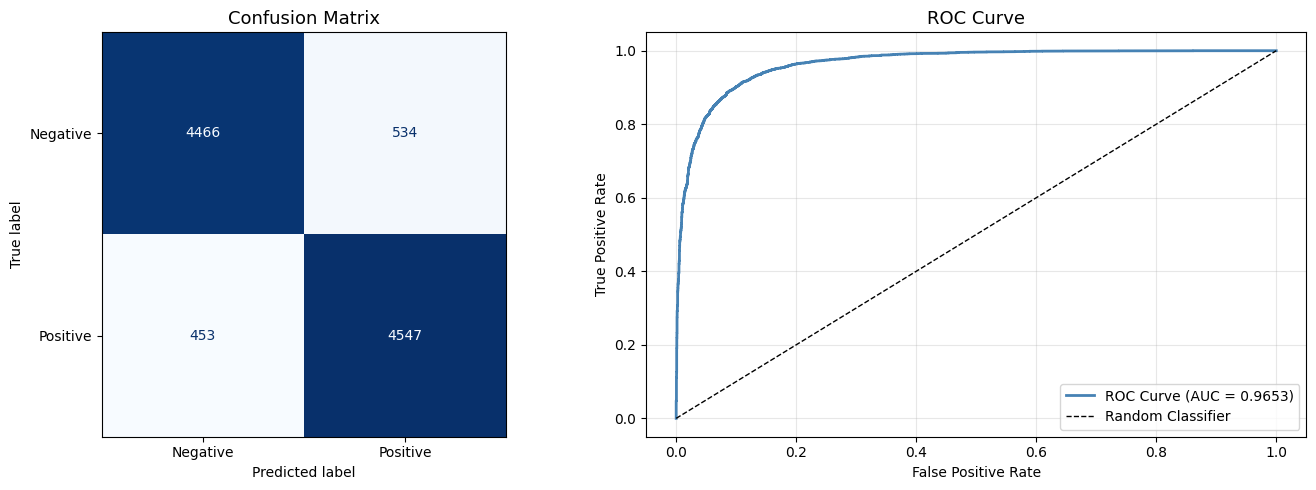

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

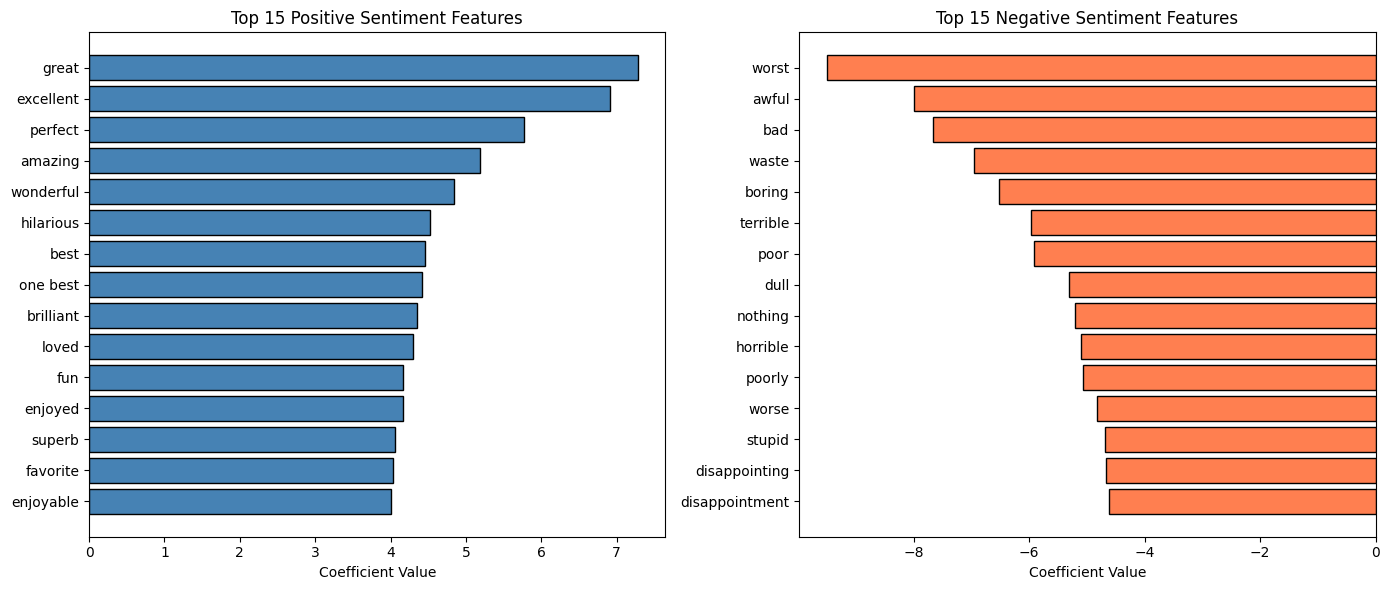

In [10]:
# Top positive and negative features from model coefficients
coef  = lr_model.coef_[0]
top_n = 15

top_pos_idx = np.argsort(coef)[-top_n:][::-1]
top_neg_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive features
axes[0].barh(
    [feature_names[i] for i in top_pos_idx],
    coef[top_pos_idx],
    color='steelblue', edgecolor='black'
)
axes[0].set_title('Top 15 Positive Sentiment Features', fontsize=12)
axes[0].set_xlabel('Coefficient Value')
axes[0].invert_yaxis()

# Negative features
axes[1].barh(
    [feature_names[i] for i in top_neg_idx],
    coef[top_neg_idx],
    color='coral', edgecolor='black'
)
axes[1].set_title('Top 15 Negative Sentiment Features', fontsize=12)
axes[1].set_xlabel('Coefficient Value')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Predict on Custom Reviews

In [11]:
def predict_sentiment(review_text):
    """Predict sentiment of any custom review string."""
    cleaned    = preprocess_text(review_text)
    processed  = tokenize_and_filter(cleaned)
    vectorized = tfidf.transform([processed])
    pred       = lr_model.predict(vectorized)[0]
    proba      = lr_model.predict_proba(vectorized)[0]
    label      = 'POSITIVE 😊' if pred == 1 else 'NEGATIVE 😞'
    conf       = proba[pred] * 100
    print(f"Review   : {review_text[:80]}...")
    print(f"Sentiment: {label}  |  Confidence: {conf:.1f}%")
    print("-" * 65)

samples = [
    "This movie was absolutely fantastic! One of the best films I have ever seen.",
    "Terrible movie. Complete waste of time and money. The acting was awful.",
    "It was okay, nothing special but not bad either. Average film."
]

for review in samples:
    predict_sentiment(review)

Review   : This movie was absolutely fantastic! One of the best films I have ever seen....
Sentiment: POSITIVE 😊  |  Confidence: 96.9%
-----------------------------------------------------------------
Review   : Terrible movie. Complete waste of time and money. The acting was awful....
Sentiment: NEGATIVE 😞  |  Confidence: 100.0%
-----------------------------------------------------------------
Review   : It was okay, nothing special but not bad either. Average film....
Sentiment: NEGATIVE 😞  |  Confidence: 99.6%
-----------------------------------------------------------------
